In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('houseprice.csv')

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.isnull().sum() # Dataset has 0 missing columns, saves us the job of data cleaning

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [5]:
df['Price'].value_counts()

Price
959222    2
149919    1
424998    1
266746    1
244020    1
         ..
295620    1
580929    1
476925    1
161119    1
482525    1
Name: count, Length: 1999, dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x1175e5690>,
 'caps': [<matplotlib.lines.Line2D at 0x1175e6990>,
 'boxes': [<matplotlib.lines.Line2D at 0x1175e4e50>],
 'medians': [<matplotlib.lines.Line2D at 0x1175e7c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x1175f05d0>],
 'means': []}

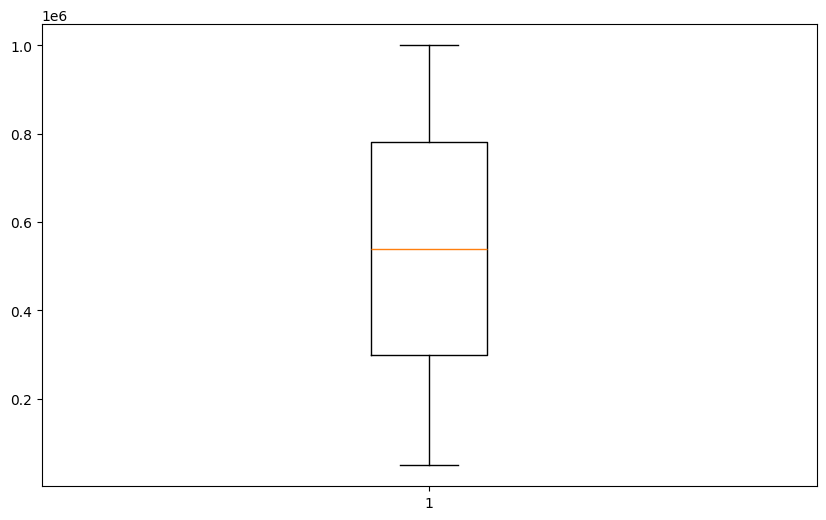

In [13]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['Price'])

In [17]:
categorical_columns = ['Location', 'Condition', 'Garage']

df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=categorical_columns, drop_first=True)

df_encoded.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


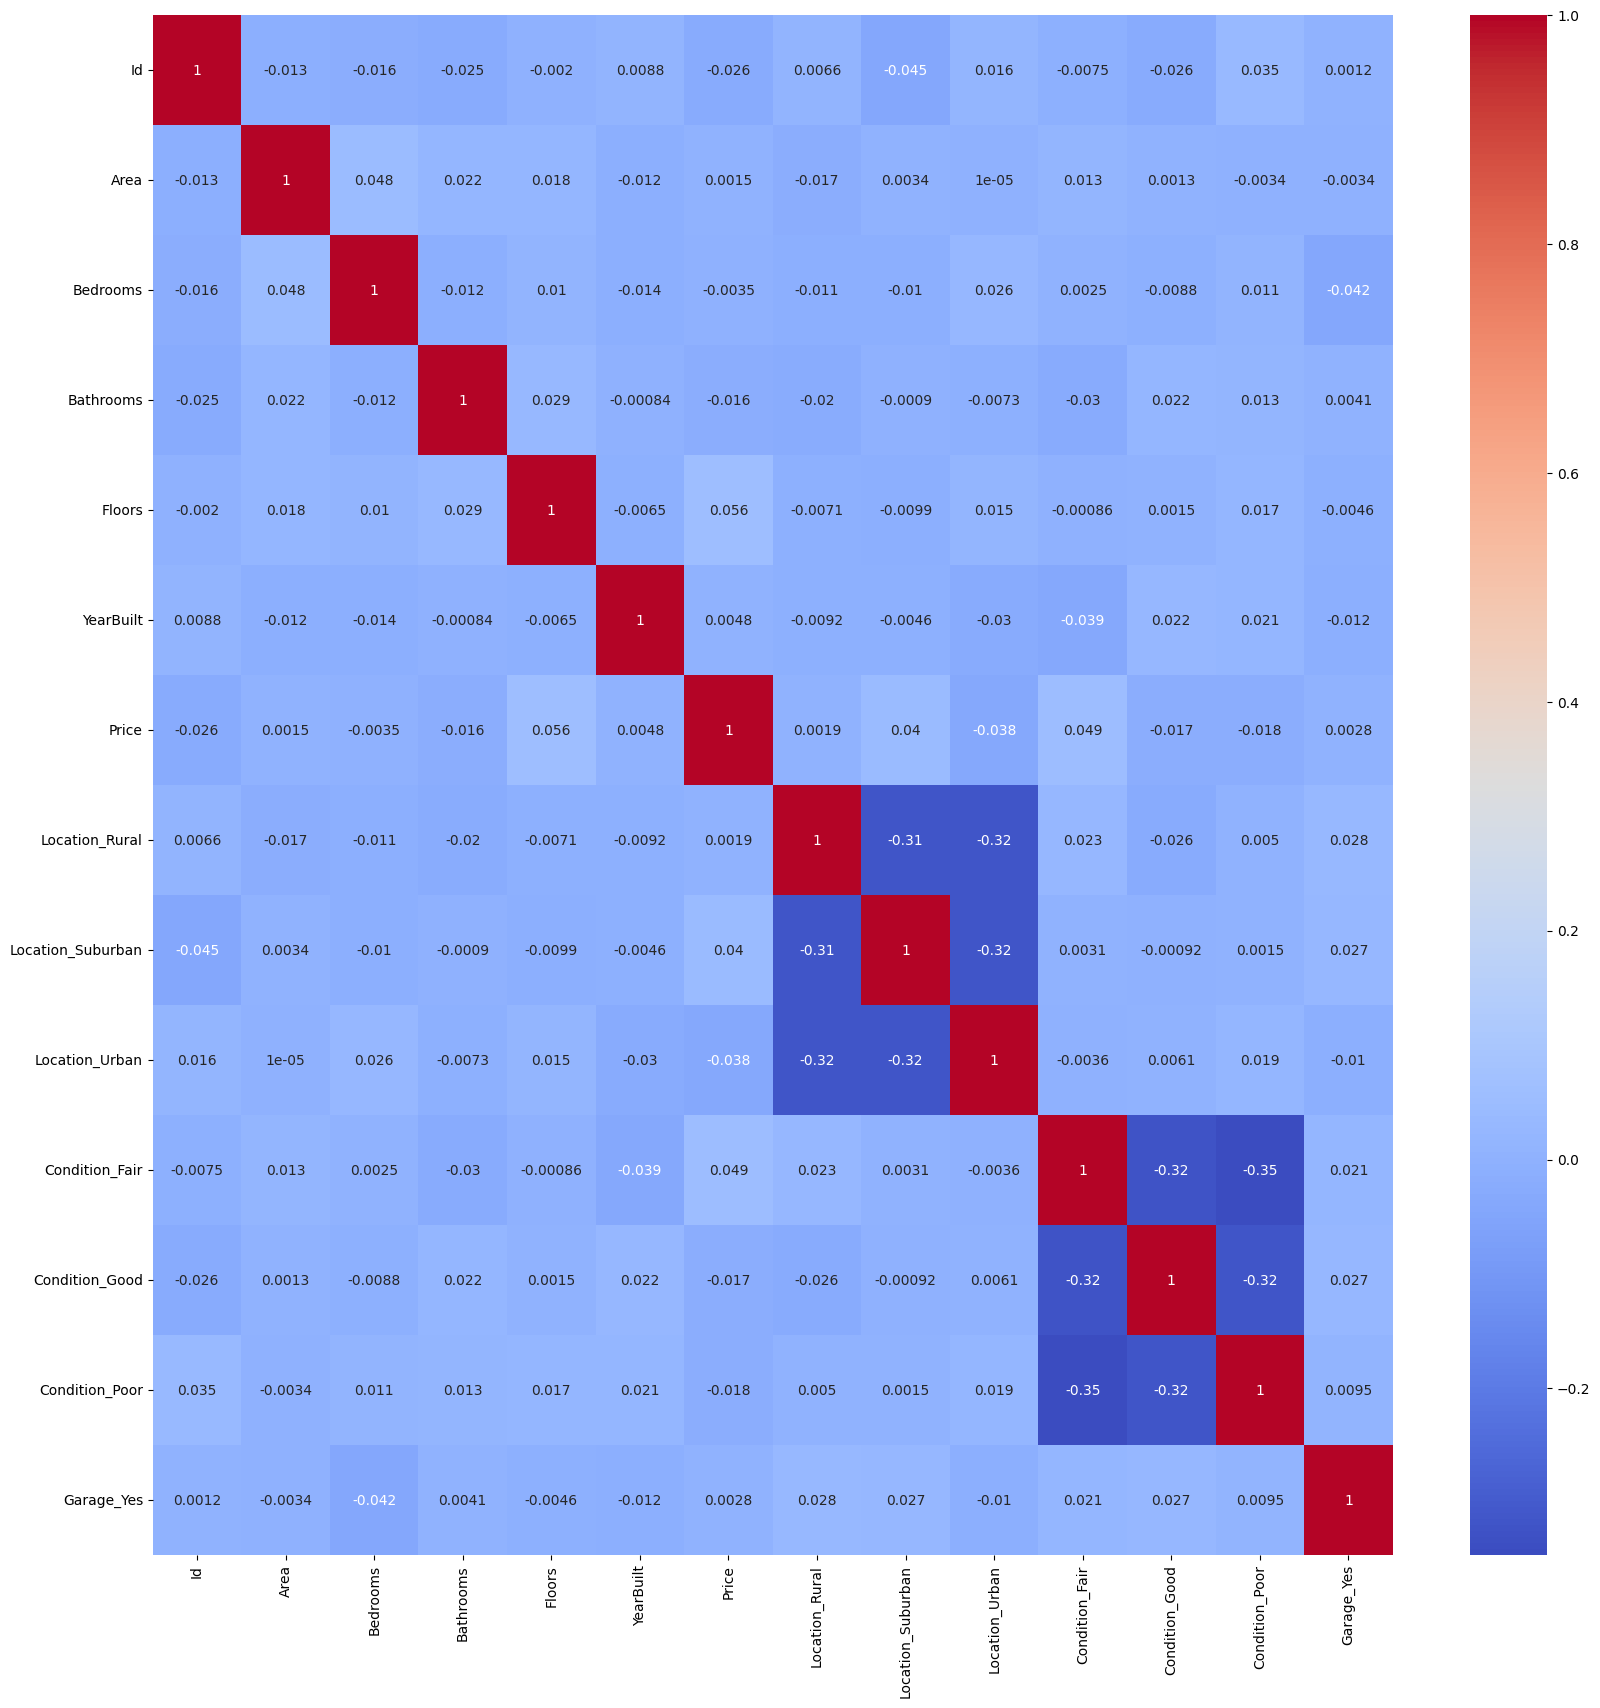

In [24]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression(fit_intercept=True)

model.fit(X_train, y_train)
print(model.score(X_test, y_test))

# Note the score is low because the data set is randomly generated :sob:

0.0017948854315001928
